In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly as plty
import plotly.express as px
import math
import geoip2.database
from user_agents import parse
import os

In [22]:
# Load df processed after first EDA
df = pd.read_csv('./data/processed_data/cybersecurity_attacks_firstEDA.csv')

# Load df before first EDA - to easily fill in na to 0 for certain columns
df0 = pd.read_csv("./data/raw/int/cybersecurity_attacks.csv")

In [23]:
df

,Timestamp,Source IP Address,Destination IP Address,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Malware Indicators,...,Attack Signature,Action Taken,Severity Level,Device Information,Network Segment,Geo-location Data,Proxy Information,Firewall Logs,IDS/IPS Alerts,Log Source
0,2023-05-30 06:33:58,103.216.15.12,84.9.164.252,31225,17616,ICMP,503,Data,HTTP,IoC Detected,...,Known Pattern B,Logged,Low,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment A,"Jamshedpur, Sikkim",150.9.97.135,Log Data,no Alert Data,Server
1,2020-08-26 07:08:30,78.199.217.198,66.191.137.154,17245,48166,ICMP,1174,Data,HTTP,IoC Detected,...,Known Pattern A,Blocked,Low,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment B,"Bilaspur, Nagaland",NaN,Log Data,no Alert Data,Firewall
2,2022-11-13 08:23:25,63.79.210.48,198.219.82.17,16811,53600,UDP,306,Control,HTTP,IoC Detected,...,Known Pattern B,Ignored,Low,Mozilla/5.0 (compatible; MSIE 9.0; Windows NT ...,Segment C,"Bokaro, Rajasthan",114.133.48.179,Log Data,Alert Data,Firewall
3,2023-07-02 10:38:46,163.42.196.10,101.228.192.255,20018,32534,UDP,385,Data,HTTP,no IoC Detected,...,Known Pattern B,Blocked,Medium,Mozilla/5.0 (Macintosh; PPC Mac OS X 10_11_5; ...,Segment B,"Jaunpur, Rajasthan",NaN,no Log Data,Alert Data,Firewall
4,2023-07-16 13:11:07,71.166.185.76,189.243.174.238,6131,26646,TCP,1462,Data,DNS,no IoC Detected,...,Known Pattern B,Blocked,Low,Mozilla/5.0 (compatible; MSIE 5.0; Windows NT ...,Segment C,"Anantapur, Tripura",149.6.110.119,no Log Data,Alert Data,Firewall
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,2023-05-26 14:08:42,26.36.109.26,121.100.75.240,31005,6764,UDP,1428,Control,HTTP,IoC Detected,...,Known Pattern A,Logged,Medium,Mozilla/5.0 (iPad; CPU iPad OS 14_2_1 like Mac...,Segment A,"Nashik, Manipur",NaN,Log Data,Alert Data,Firewall
39996,2023-03-27 00:38:27,17.21.163.81,196.108.134.78,2553,28091,UDP,1184,Control,HTTP,IoC Detected,...,Known Pattern A,Logged,High,Mozilla/5.0 (Windows; U; Windows 98; Win 9x 4....,Segment C,"Vadodara, Mizoram",60.51.30.46,Log Data,no Alert Data,Firewall
39997,2022-03-31 01:45:49,162.35.217.57,98.107.0.15,22505,25152,UDP,1043,Data,DNS,IoC Detected,...,Known Pattern B,Blocked,Low,Mozilla/5.0 (Windows; U; Windows NT 4.0) Apple...,Segment C,"Mahbubnagar, Himachal Pradesh",NaN,Log Data,Alert Data,Server
39998,2023-09-22 18:32:38,208.72.233.205,173.79.112.252,20013,2703,UDP,483,Data,FTP,IoC Detected,...,Known Pattern B,Ignored,Low,Mozilla/5.0 (X11; Linux i686) AppleWebKit/536....,Segment B,"Rourkela, Arunachal Pradesh",137.76.130.8,Log Data,no Alert Data,Server


### Columns with missing values that can be replaced with 1 and 0: 
1. Malware Indicators => IoC Detected or missing value => IoC Detected changed to 1, missing value changed to 0
2. Alerts/Warnings => Alert Triggered or missing value => Alert Triggered changed to 1, missing value changed to 0
3. Firewall Logs => Log Data or missing value => Log Data changed to 1, missing value changed to 0
4. IDS/IPS Alerts => Alert Data or missing value => Alert Data changed to 1, missing value changed to 0

In [ ]:
# Replace missing values with 0 for specific columns, to convert easily into binary categorical
df['Malware Indicators'] = df0['Malware Indicators']
df['Alerts/Warnings'] = df0['Alerts/Warnings']
df['IDS/IPS Alerts'] = df0['IDS/IPS Alerts']

In [39]:
df.head(10)

,Timestamp,Source IP Address,Destination IP Address,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Malware Indicators,...,Severity Level,Device Information,Network Segment,Geo-location Data,Proxy Information,Firewall Logs,IDS/IPS Alerts,Log Source,is_weekend,hours_div
0,2023-05-30 06:33:58,103.216.15.12,84.9.164.252,31225,17616,ICMP,503,Data,HTTP,1,...,Low,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment A,"Jamshedpur, Sikkim",150.9.97.135,1,0,Server,0,2
1,2020-08-26 07:08:30,78.199.217.198,66.191.137.154,17245,48166,ICMP,1174,Data,HTTP,1,...,Low,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment B,"Bilaspur, Nagaland",NaN,1,0,Firewall,0,2
2,2022-11-13 08:23:25,63.79.210.48,198.219.82.17,16811,53600,UDP,306,Control,HTTP,1,...,Low,Mozilla/5.0 (compatible; MSIE 9.0; Windows NT ...,Segment C,"Bokaro, Rajasthan",114.133.48.179,1,1,Firewall,1,2
3,2023-07-02 10:38:46,163.42.196.10,101.228.192.255,20018,32534,UDP,385,Data,HTTP,0,...,Medium,Mozilla/5.0 (Macintosh; PPC Mac OS X 10_11_5; ...,Segment B,"Jaunpur, Rajasthan",NaN,1,1,Firewall,1,2
4,2023-07-16 13:11:07,71.166.185.76,189.243.174.238,6131,26646,TCP,1462,Data,DNS,0,...,Low,Mozilla/5.0 (compatible; MSIE 5.0; Windows NT ...,Segment C,"Anantapur, Tripura",149.6.110.119,1,1,Firewall,1,3
5,2022-10-28 13:14:27,198.102.5.160,147.190.155.133,17430,52805,UDP,1423,Data,HTTP,0,...,Medium,Opera/8.58.(X11; Linux i686; nl-NL) Presto/2.9...,Segment C,"Aurangabad, Meghalaya",NaN,1,0,Server,0,3
6,2022-05-16 17:55:43,97.253.103.59,77.16.101.53,26562,17416,TCP,379,Data,DNS,0,...,High,Opera/9.24.(X11; Linux i686; fa-IR) Presto/2.9...,Segment A,"Eluru, Manipur",NaN,1,0,Server,0,3
7,2023-02-12 07:13:17,11.48.99.245,178.157.14.116,34489,20396,ICMP,1022,Data,DNS,1,...,High,Mozilla/5.0 (Macintosh; U; PPC Mac OS X 10_7_6...,Segment A,"Phagwara, Andhra Pradesh",192.31.159.5,1,1,Firewall,1,2
8,2023-06-27 11:02:56,49.32.208.167,72.202.237.9,56296,20857,TCP,1281,Control,FTP,1,...,High,Mozilla/5.0 (Macintosh; U; PPC Mac OS X 10_5_8...,Segment B,"Ambala, Tripura",NaN,1,1,Server,0,2
9,2021-08-15 22:29:04,114.109.149.113,160.88.194.172,37918,50039,UDP,224,Data,HTTP,0,...,Medium,Mozilla/5.0 (Windows; U; Windows NT 6.0) Apple...,Segment A,"Rampur, Mizoram",87.128.245.244,1,0,Server,1,4


In [26]:
# df['Malware Indicators'] = df['Malware Indicators'].apply(lambda x: 1 if pd.notna(x) else 0)
# use map instead of apply to affect more than one columns (dataframe)
cols_to_bin = ['Malware Indicators', 'Alerts/Warnings', 'Firewall Logs', 'IDS/IPS Alerts']
df[cols_to_bin] = df[cols_to_bin].map(lambda x: 1 if pd.notna(x) else 0)

### Timestamp - Feature Engineering & Analysis

In [ ]:
# Convert object to datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

In [ ]:
# Create new feature: is_weekend. In real life, some attacks might happen more during weekend then weekdays
df['is_weekend'] = df['Timestamp'].dt.dayofweek.isin([5, 6]).map({True: 1, False: 0})

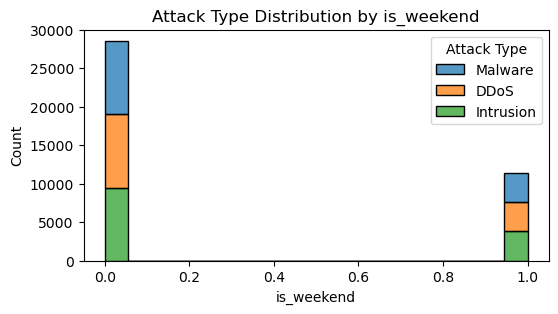

In [ ]:
# Attack Type Distribution by is_weekend => fair distribution
# Conclusion: not sure if finally great feature cause it shows fair distribution ? Keep for now, maybe can help when combine with other features
plt.figure(figsize=(6,3))
sns.histplot(x= "is_weekend", hue="Attack Type", multiple = "stack", data=df)
plt.title("Attack Type Distribution by is_weekend")
plt.show()

In [ ]:
# Create new feature: hours_div. In real life, attack might happen midnight to avoid detection (Malware), or during work hours to cause more disruption (DDos)?
# First bin attempt: divide to 4 parts (0-5, 6-11, 12-17, 18-23)
# fair distribution of total rows for these bins
df['hours_div'] = pd.to_datetime(df['Timestamp']).apply(
    lambda x: "0-5" if 0 <= x.hour <= 5 else
              "6-11" if 6 <= x.hour <= 11 else
              "12-17" if 12 <= x.hour <= 17 else
              "18-23" # for 18-23
)

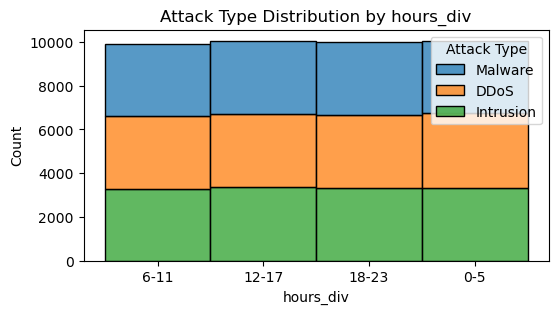

In [42]:
# Attack Type Distribution by hours_div => fair distribution
# Conclusion: not sure if finally great feature cause it shows fair distribution ? Keep for now, maybe can help when combine with other features
plt.figure(figsize=(6,3))
sns.histplot(x= "hours_div", hue="Attack Type", multiple = "stack", data=df)
plt.title("Attack Type Distribution by hours_div")
plt.show()

In [53]:
# Second bin attempt: divide to 2 parts (0-5, 6-23)
# Data distribution 25% for 0-5 and 75% for 6-23
df['hours_div'] = pd.to_datetime(df['Timestamp']).apply(
    lambda x: "0-5" if 0 <= x.hour <= 5 else
              "6-23" # for 6-23
)

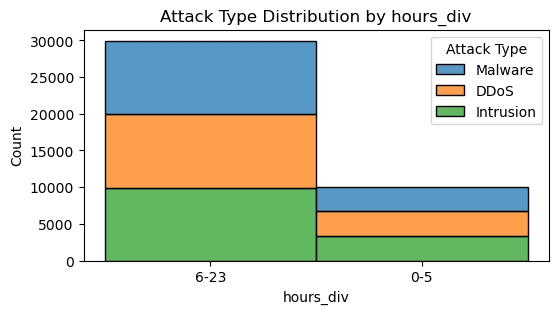

In [54]:
# Attack Type Distribution by hours_div => fair distribution
# Conclusion: not sure if finally great feature cause it shows fair distribution ? Keep for now, maybe can help when combine with other features
plt.figure(figsize=(6,3))
sns.histplot(x= "hours_div", hue="Attack Type", multiple = "stack", data=df)
plt.title("Attack Type Distribution by hours_div")
plt.show()

In [55]:
# Third bin attempt: divide to 2 parts : out of office hours (night) (6-20, 21-5)
# Data distribution 63% for 6-20 and 37% for 21-5
df['hours_div'] = pd.to_datetime(df['Timestamp']).apply(
    lambda x: "21-5" if (x.hour >= 21 or x.hour <= 5) else "6-20"
)

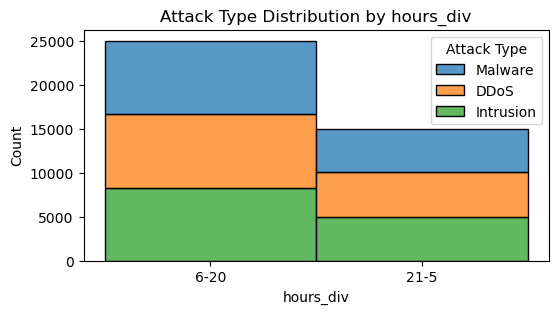

In [56]:
# Attack Type Distribution by hours_div => fair distribution
# Conclusion: not sure if finally great feature cause it shows fair distribution ? Keep for now, maybe can help when combine with other features
plt.figure(figsize=(6,3))
sns.histplot(x= "hours_div", hue="Attack Type", multiple = "stack", data=df)
plt.title("Attack Type Distribution by hours_div")
plt.show()

#### Not sure need new feature for hours divisions, and if yes, which type of bins?

# Columns to delete : Timestamp

### IP Addresses - Feature Engineering & Analysis

In [ ]:
# Check if there are lots of repeating subnets in IP addresses
# Split all IPs to /24 subnet ==> local subnet/Single host
def splitIP24(ip):
    if pd.isna(ip):
        return pd.NA
    return ".".join(ip.split(".")[:3])

# Split all IPs to /16 subnet ==> network owner/region (ISP/backbone provider)
def splitIP16(ip):
    if pd.isna(ip):
        return pd.NA
    return ".".join(ip.split(".")[:2])

df['Source IP Address_24'] = df['Source IP Address'].apply(splitIP24)
df['Source IP Address_16'] = df['Source IP Address'].apply(splitIP16)

df['Destination IP Address_24'] = df['Destination IP Address'].apply(splitIP24)
df['Destination IP Address_16'] = df['Destination IP Address'].apply(splitIP16)

df['Proxy Information_24'] = df['Proxy Information'].apply(splitIP24)
df['Proxy Information_16'] = df['Proxy Information'].apply(splitIP16)

In [ ]:
df['Source IP Address_24'].nunique(), df['Source IP Address_16'].nunique()
# (39941, 28716)

(39941, 28716)

In [ ]:
df['Destination IP Address_24'].nunique(), df['Destination IP Address_16'].nunique()
# (39958, 28670)

(39958, 28670)

In [ ]:
df['Proxy Information_24'].nunique(), df['Proxy Information_16'].nunique()
# (20130, 16925)

(20130, 16925)

In [70]:
# RECOPY function to drop column(s) from 01_EDA_first
def drop_columns(df, columns):
    """
    Drop one or more columns from a DataFrame if they exist.
    """
    if isinstance(columns, str):
        columns = [columns]
    cols_to_drop = [col for col in columns if col in df.columns]
    return df.drop(columns=cols_to_drop, inplace=False)

In [ ]:
# Drop these 6 columns - not interesting after checking unique counts, can cause overfitting or bias
df = drop_columns(df, ['Source IP Address_24', 'Source IP Address_16', 
'Destination IP Address_24', 'Destination IP Address_16', 
'Proxy Information_24', 'Proxy Information_16'])

In [74]:
# Check private range
# • 10.0.0.0 – 10.255.255.255 
# • 172.16.0.0 – 172.31.255.255 
# • 192.168.0.0 – 192.168.255.255

def isPrivateIP(ip):
    if pd.isna(ip):
        return pd.NA
    octets = ip.split(".")
    first = int(octets[0])
    second = int(octets[1])
    if first == 10:
        return True
    elif first == 172 and 16 <= second <= 31:
        return True
    elif first == 192 and second == 168:
        return True
    else:
        return False

df['isPrivate_Source'] = df['Source IP Address'].apply(isPrivateIP)
df['isPrivate_Destination'] = df['Destination IP Address'].apply(isPrivateIP)
df['isPrivate_Proxy'] = df['Proxy Information'].apply(isPrivateIP)

In [ ]:
df['isPrivate_Source'].value_counts(dropna=False) # True = 181
df['isPrivate_Destination'].value_counts(dropna=False) # True = 174
df['isPrivate_Proxy'].value_counts(dropna=False) # True = 84

isPrivate_Proxy
False    20065
<NA>     19851
True        84
Name: count, dtype: int64

In [79]:
# Less than 1% of total private IPs, not interesting to keep for ML modeling, drop
df = drop_columns(df, ['isPrivate_Source', 'isPrivate_Destination', 'isPrivate_Proxy'])

In [ ]:
# Create new feature of continent and country for IP addresses
import geoip2.errors
with geoip2.database.Reader('./data/raw/ext/GeoLite2-Country_20251212/GeoLite2-Country.mmdb') as reader:
    def _lookup_ip(ip):
        # 1. Handle missing/NA values
        if not ip or pd.isna(ip):
            return {
                'ContinentName': pd.NA,
                'CountryName': pd.NA,
            }
        
        # 2. Perform external lookup
        try:
            response = reader.country(ip)
            
            # 3. RETURN A DICTIONARY of all desired features
            return {
                'ContinentName': response.continent.name,
                'CountryName': response.country.name,
            }
        
        except geoip2.errors.AddressNotFoundError:
            # 4. Return NA dictionary for not found IPs
            return {
                'ContinentName': pd.NA,
                'CountryName': pd.NA,
            }
        except Exception:
            # 5. Return NA dictionary for other errors
            return {
                'ContinentName': pd.NA,
                'CountryName': pd.NA,
            }

    # --- Applying the Function ---
    geo_results_sourceIP = df['Source IP Address'].apply(_lookup_ip)
    geo_results_destIP = df['Destination IP Address'].apply(_lookup_ip)
    geo_results_proxyIP = df['Proxy Information'].apply(_lookup_ip)

    # print('geo_results_sourceIP', geo_results_sourceIP)
    # Convert list of dictionaries to DataFrame
    geo_df_sourceIP = pd.DataFrame(geo_results_sourceIP.tolist(), index=geo_results_sourceIP.index)
    # print('geo_df_sourceIP', geo_df_sourceIP)
    geo_df_destIP = pd.DataFrame(geo_results_destIP.tolist(), index=geo_results_destIP.index)
    # print('geo_df_destIP', geo_df_destIP)

    geo_df_proxyIP = pd.DataFrame(geo_results_proxyIP.tolist(), index=geo_results_proxyIP.index)

    # test to df_test before real df
    # df_test.loc[:, ('ContinentName_Source', 'CountryName_Source')] = geo_df_sourceIP[['ContinentName', 'CountryName']]
    # Source IP
    df['ContinentName_Source'] = geo_df_sourceIP['ContinentName']
    df['CountryName_Source'] = geo_df_sourceIP['CountryName']
    # df.loc[:, ('ContinentName_Source', 'CountryName_Source')] = geo_df_sourceIP[['ContinentName', 'CountryName']]
    # print('am here')
    
    # Destination IP
    df['ContinentName_Destination'] = geo_df_destIP['ContinentName']
    df['CountryName_Destination'] = geo_df_destIP['CountryName']

    # Proxy IP
    df['ContinentName_Proxy'] = geo_df_proxyIP['ContinentName']
    df['CountryName_Proxy'] = geo_df_proxyIP['CountryName']

In [ ]:
# Calculate total for each ContinentName_Source
# Maybe take top 3 (44%, 25%, 21%) and put others for the rest
continent_counts = df['ContinentName_Source'].value_counts()
continent_pct = (df['ContinentName_Source'].value_counts(normalize=True) * 100).round(2)

continent_summary = pd.DataFrame({
    'Count': continent_counts,
    'Percentage': continent_pct
})

continent_summary

,Count,Percentage
ContinentName_Source,,
North America,17562,44.30
Asia,10045,25.34
Europe,8472,21.37
South America,1690,4.26
Africa,1212,3.06
Oceania,661,1.67
Antarctica,1,0.00


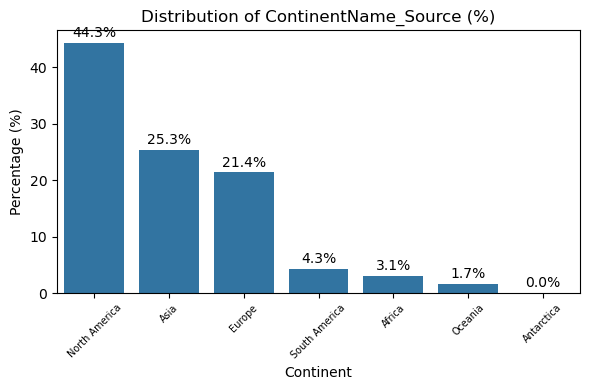

In [104]:
# Calculate percentage for each ContinentName_Source
continent_pct = df['ContinentName_Source'].value_counts(normalize=True) * 100

plt.figure(figsize=(6,4))
ax = sns.barplot(x=continent_pct.index, y=continent_pct.values)
plt.title("Distribution of ContinentName_Source (%)")
plt.ylabel("Percentage (%)")
plt.xlabel("Continent")
plt.xticks(rotation=45, fontsize=7)

# Annotate each bar with the percentage value
for i, v in enumerate(continent_pct.values):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
# Calculate total for each ContinentName_Destination
# Maybe take top 3 (44%, 25%, 21%) and put others for the rest
continent_counts = df['ContinentName_Destination'].value_counts()
continent_pct = (df['ContinentName_Destination'].value_counts(normalize=True) * 100).round(2)

continent_summary = pd.DataFrame({
    'Count': continent_counts,
    'Percentage': continent_pct
})

continent_summary

,Count,Percentage
ContinentName_Destination,,
North America,17538,44.22
Asia,10202,25.72
Europe,8457,21.32
South America,1655,4.17
Africa,1194,3.01
Oceania,616,1.55


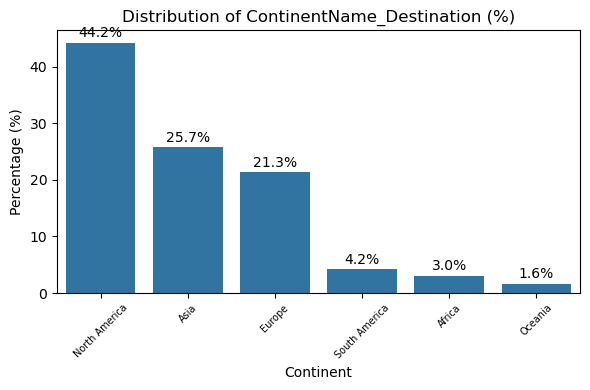

In [105]:
# Calculate percentage for each ContinentName_Destination
continent_pct = df['ContinentName_Destination'].value_counts(normalize=True) * 100

plt.figure(figsize=(6,4))
ax = sns.barplot(x=continent_pct.index, y=continent_pct.values)
plt.title("Distribution of ContinentName_Destination (%)")
plt.ylabel("Percentage (%)")
plt.xlabel("Continent")
plt.xticks(rotation=45, fontsize=7)

# Annotate each bar with the percentage value
for i, v in enumerate(continent_pct.values):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
# Calculate total for each ContinentName_Proxy
# Maybe take top 3 (43%, 26%, 21%) and put others for the rest
continent_counts = df['ContinentName_Proxy'].value_counts()
continent_pct = (df['ContinentName_Proxy'].value_counts(normalize=True) * 100).round(2)

continent_summary = pd.DataFrame({
    'Count': continent_counts,
    'Percentage': continent_pct
})

continent_summary

,Count,Percentage
ContinentName_Proxy,,
North America,8752,43.80
Asia,5232,26.18
Europe,4242,21.23
South America,819,4.10
Africa,609,3.05
Oceania,329,1.65


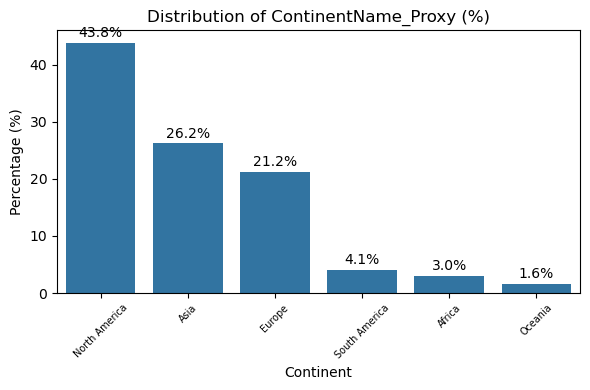

In [108]:
# Calculate percentage for each ContinentName_Proxy
continent_pct = df['ContinentName_Proxy'].value_counts(normalize=True) * 100

plt.figure(figsize=(6,4))
ax = sns.barplot(x=continent_pct.index, y=continent_pct.values)
plt.title("Distribution of ContinentName_Proxy (%)")
plt.ylabel("Percentage (%)")
plt.xlabel("Continent")
plt.xticks(rotation=45, fontsize=7)

# Annotate each bar with the percentage value
for i, v in enumerate(continent_pct.values):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
# Calculate percentage for each CountryName_Source
country_counts = df['CountryName_Source'].value_counts()
country_pct = (df['CountryName_Source'].value_counts(normalize=True) * 100).round(2)

country_summary = pd.DataFrame({
    'Count': country_counts,
    'Percentage': country_pct
})

country_summary

,Count,Percentage
CountryName_Source,,
United States,16356,41.26
China,3663,9.24
Japan,2190,5.52
Germany,1475,3.72
United Kingdom,1420,3.58
...,...,...
Nauru,1,0.00
Montserrat,1,0.00
Heard and McDonald Islands,1,0.00


In [127]:
# Calculate percentage for each CountryName_Destination
country_counts = df['CountryName_Destination'].value_counts()
country_pct = (df['CountryName_Destination'].value_counts(normalize=True) * 100).round(2)

country_summary = pd.DataFrame({
    'Count': country_counts,
    'Percentage': country_pct
})

country_summary

,Count,Percentage
CountryName_Destination,,
United States,16262,41.00
China,3729,9.40
Japan,2143,5.40
Germany,1423,3.59
United Kingdom,1406,3.55
...,...,...
Liechtenstein,1,0.00
Belize,1,0.00
Antigua and Barbuda,1,0.00


In [ ]:
# Calculate percentage for each CountryName_Proxy
country_counts = df['CountryName_Proxy'].value_counts()
country_pct = (df['CountryName_Proxy'].value_counts(normalize=True) * 100).round(2)

country_summary = pd.DataFrame({
    'Count': country_counts,
    'Percentage': country_pct
})

country_summary

,Count,Percentage
CountryName_Proxy,,
United States,8150,40.79
China,1872,9.37
Japan,1113,5.57
United Kingdom,732,3.66
Germany,723,3.62
...,...,...
American Samoa,1,0.01
Mongolia,1,0.01
Afghanistan,1,0.01


In [ ]:
df['CountryName_Source'].nunique(), df['CountryName_Destination'].nunique(), df['CountryName_Proxy'].nunique()
# (186, 179, 162)
# Conclusion: high cardinality, may cause bias or overfitting
# Top 1 country has around 40%,  Top 2 - 9%, Top 3 - 5%, rest below 5%
# Either take top 3 country or drop all

(186, 179, 162)

In [132]:
# Drop country_name for all IP addresses, too avoid overfitting or bias
df = drop_columns(df, ['CountryName_Source', 'CountryName_Destination', 'CountryName_Proxy'])

In [ ]:
# Fill missing values in Proxy Information as noProxy
df['Proxy Information'] = df['Proxy Information'].fillna('noProxy')

In [137]:
# Create new feature for IP addresses (Source, Destination, Proxy) by IP class
# https://www.geeksforgeeks.org/computer-networks/introduction-of-classful-ip-addressing/
# Class A = 0-127 => very large networks
# Class B = 128-191 => medium-large networks
# Class C = 192-223 => small networks
# Class D = 224-239 => multicast communication
# Class E = 240-255 => experimental and research purposes
def get_ip_class(ip):
    first_octet = int(ip.split('.')[0])
    if 0 <= first_octet <= 127:
        return 'A'
    elif 128 <= first_octet <= 191:
        return 'B'
    elif 192 <= first_octet <= 223:
        return 'C'
    elif 224 <= first_octet <= 239:
        return 'D'
    elif 240 <= first_octet <= 255:
        return 'E'
    else:
        return 'Unknown'

df['Source IP_Class'] = df['Source IP Address'].apply(get_ip_class)
df['Destination IP_Class'] = df['Destination IP Address'].apply(get_ip_class)
df['Proxy_Class'] = df['Proxy Information'].apply(lambda x: 'noProxy' if x == 'noProxy' else get_ip_class(x))

In [142]:
count = df['Source IP_Class'].value_counts()
pct = (df['Source IP_Class'].value_counts(normalize=True) * 100).round(2)

Source_IP_Class_summary = pd.DataFrame({
    'Count': count,
    'Percentage': pct
})

Source_IP_Class_summary

,Count,Percentage
Source IP_Class,,
A,22752,56.88
B,11452,28.63
C,5796,14.49


In [143]:
count = df['Destination IP_Class'].value_counts()
pct = (df['Destination IP_Class'].value_counts(normalize=True) * 100).round(2)

Destination_IP_Class_summary = pd.DataFrame({
    'Count': count,
    'Percentage': pct
})

Destination_IP_Class_summary

,Count,Percentage
Destination IP_Class,,
A,22723,56.81
B,11477,28.69
C,5800,14.50


In [144]:
count = df['Proxy_Class'].value_counts()
pct = (df['Proxy_Class'].value_counts(normalize=True) * 100).round(2)

Proxy_Class_summary = pd.DataFrame({
    'Count': count,
    'Percentage': pct
})

Proxy_Class_summary

,Count,Percentage
Proxy_Class,,
noProxy,19851,49.63
A,11491,28.73
B,5754,14.38
C,2904,7.26


In [145]:
# Drop columns 'Source IP Address', 'Destination IP Address' and 'Proxy Information'
# as they are no longer needed
df = drop_columns(df, ['Source IP Address', 'Destination IP Address', 'Proxy Information'])

In [ ]:
# Analyse of Source Port
df['Destination Port'].nunique(), df['Source Port'].nunique()
# (29895, 29761)
# Can't use these features, too many distinct values

(29895, 29761)

In [ ]:
# 8333 unique same source ports appear more than once of total 29761 distinct source ports, means around 30%
# Can't use, may cause overfitting or bias
df['Source Port'].value_counts()[df['Source Port'].value_counts() > 1]

Source Port
41341    6
31656    5
45874    5
15669    5
35304    5
        ..
22301    2
25913    2
6722     2
19207    2
25022    2
Name: count, Length: 8333, dtype: int64

In [148]:
# 8217 unique destination ports appear more than once
# of total 29895 unique destination ports, means around 27.5%
# Maybe can't use this cause when we divide the dataset in train/test, we won't have same result of frequency of destination port appearing
df['Destination Port'].value_counts()[df['Destination Port'].value_counts() > 1]

Destination Port
7508     6
34117    6
39887    5
15150    5
30804    5
        ..
60667    2
43767    2
14773    2
50174    2
20649    2
Name: count, Length: 8217, dtype: int64

In [152]:
# Create new features for ports based on port categories
# HTTPS 443, SSH 22, DNS 53, FTP 20-21
# Well-known (0–1023) → common services (HTTP, FTP, DNS, etc.) 
# User/Registered Ports (1024-49151) → used by Server, Application, Database, VPN (HTTP alternate 8080, MySQL 3306) 
# Dynamic and/or Private Ports (49152-65535) → temporary/ephemeral ports for outgoing connections, used by Clients. Rapid rotation may signal botnets. 
# Plot to see distribution of these different ports vs packet length ?
def portCategory(port):
    if pd.isna(port):
        return pd.NA
    elif 0 <= port <= 1023:
        return 'Wellknown'
    elif 1024 <= port <= 49151:
        return 'Registered'
    elif 49152 <= port <= 65535:
        return 'Dynamic'
    else:
        return 'Invalid'

df['Source Port_Cat'] = df['Source Port'].apply(portCategory)
df['Destination Port_Cat'] = df['Destination Port'].apply(portCategory)

In [ ]:
# Drop Source Port and Destination Port as no longer needed
df = drop_columns(df, ['Source Port', 'Destination Port'])

In [ ]:
# No anomaly detected, seems pretty fairly spread
df['Packet Length'].describe()

count    40000.000000
mean       781.452725
std        416.044192
min         64.000000
25%        420.000000
50%        782.000000
75%       1143.000000
max       1500.000000
Name: Packet Length, dtype: float64

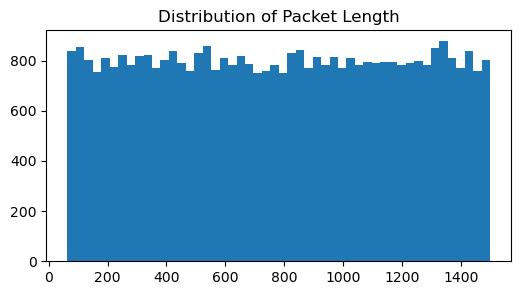

In [ ]:
# Packet Length are spread almost evenly
plt.figure(figsize=(6,3))
plt.hist(df['Packet Length'], bins=50)
plt.title("Distribution of Packet Length")
plt.show()

In [180]:
# Option 1 - Create new feature for Packet Length - by octet bins ?
# Conclusion: First three bins have so small percentage => 0-64 - less than 1%, 64-128 - 5%, 128-258 - 8%
# May cause bias or overfitting for these three bins, maybe finally not good to use?
df['Packet Length_Bin'] = pd.cut(
    df['Packet Length'], 
    bins=[0, 64, 128, 256, 512, 1024, 2048], # max value is 2048
    labels=['0-64', '64-128', '128-256', '256-512', '512-1024', '1024-2048']
)

ct_percentage = pd.crosstab(df['Packet Length_Bin'], df['Attack Type'], normalize='index') * 100
ct_percentage['Total %'] = ct_percentage.sum(axis=1)
ct_percentage = ct_percentage.round(2)
print(ct_percentage)
print("="*100)

ct_qty = pd.crosstab(df['Packet Length_Bin'], df['Attack Type'])
ct_qty['Total'] = ct_qty.sum(axis=1)
grand_total = ct_qty['Total'].sum()
ct_qty['% bin of Total'] = (ct_qty['Total'] / grand_total * 100).round(2)
ct_qty.loc['Total Attack'] = ct_qty.sum(axis = 0)
# ct_qty.loc['Total Attack', '% bin of Total'] = 100.00
print(ct_qty)

Attack Type         DDoS  Intrusion  Malware  Total %
Packet Length_Bin                                    
0-64               51.52      24.24    24.24    100.0
64-128             32.51      33.32    34.18    100.0
128-256            33.93      34.22    31.85    100.0
256-512            32.69      33.42    33.89    100.0
512-1024           33.53      32.69    33.78    100.0
1024-2048          34.09      33.26    32.65    100.0
Attack Type           DDoS  Intrusion  Malware    Total  % bin of Total
Packet Length_Bin                                                      
0-64                  17.0        8.0      8.0     33.0            0.08
64-128               605.0      620.0    636.0   1861.0            4.65
128-256             1192.0     1202.0   1119.0   3513.0            8.78
256-512             2335.0     2387.0   2421.0   7143.0           17.86
512-1024            4751.0     4631.0   4786.0  14168.0           35.42
1024-2048           4528.0     4417.0   4337.0  13282.0         

In [181]:
# Option 2 - Create new feature for Packet Length - by quartile
# Conclusion: more fairly spread bins, may be better to use than option 1 ?
df['Packet Length_Quartile'] = pd.cut(
    df['Packet Length'], 
    bins=[64, 425, 789, 1150, 1500], # max value is 2048
    labels=['Q1: 64-425', 'Q2: 426-789', 'Q3: 790-1150', 'Q4: 1151-1500']
)

ct_percentage = pd.crosstab(df['Packet Length_Quartile'], df['Attack Type'], normalize='index') * 100
ct_percentage['Total %'] = ct_percentage.sum(axis=1)
ct_percentage = ct_percentage.round(2)
print(ct_percentage)
print("="*100)

ct_qty = pd.crosstab(df['Packet Length_Quartile'], df['Attack Type'])
ct_qty['Total'] = ct_qty.sum(axis=1)
grand_total = ct_qty['Total'].sum()
ct_qty['% bin of Total'] = (ct_qty['Total'] / grand_total * 100).round(2)
ct_qty.loc['Total Attack'] = ct_qty.sum(axis = 0)
# ct_qty.loc['Total Attack', '% bin of Total'] = 100.00
print(ct_qty)

Attack Type              DDoS  Intrusion  Malware  Total %
Packet Length_Quartile                                    
Q1: 64-425              33.21      33.97    32.82    100.0
Q2: 426-789             33.58      32.10    34.32    100.0
Q3: 790-1150            33.22      33.21    33.56    100.0
Q4: 1151-1500           34.23      33.39    32.38    100.0
Attack Type                DDoS  Intrusion  Malware    Total  % bin of Total
Packet Length_Quartile                                                      
Q1: 64-425               3357.0     3434.0   3317.0  10108.0           25.29
Q2: 426-789              3373.0     3225.0   3448.0  10046.0           25.14
Q3: 790-1150             3326.0     3325.0   3360.0  10011.0           25.05
Q4: 1151-1500            3355.0     3273.0   3174.0   9802.0           24.53
Total Attack            13411.0    13257.0  13299.0  39967.0          100.01


In [169]:
# No anomaly detected, seems pretty fairly spread
df['Anomaly Scores'].describe()

count    40000.000000
mean        50.113473
std         28.853598
min          0.000000
25%         25.150000
50%         50.345000
75%         75.030000
max        100.000000
Name: Anomaly Scores, dtype: float64

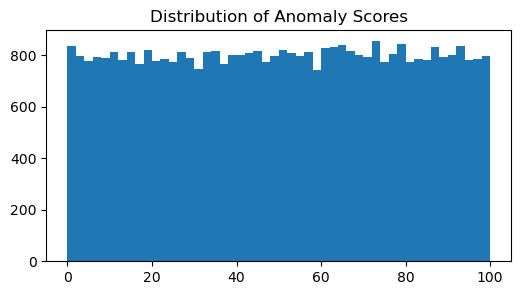

In [171]:
# Anomaly Scores are spread almost evenly
plt.figure(figsize=(6,3))
plt.hist(df['Anomaly Scores'], bins=50)
plt.title("Distribution of Anomaly Scores")
plt.show()

In [182]:
# Create new feature for Anomaly Scores - by quartile
df['Anomaly Scores_Quartile'] = pd.cut(
    df['Anomaly Scores'],
    bins=[0, 25, 50, 75, 100],
    labels=['Low (0-25)', 'Medium (25-50)', 'High (50-75)', 'Critical (75-100)']
)

ct_percentage = pd.crosstab(df['Anomaly Scores_Quartile'], df['Attack Type'], normalize='index') * 100
ct_percentage['Total %'] = ct_percentage.sum(axis=1)
ct_percentage = ct_percentage.round(2)
print(ct_percentage)
print("="*100)

ct_qty = pd.crosstab(df['Anomaly Scores_Quartile'], df['Attack Type'])
ct_qty['Total'] = ct_qty.sum(axis=1)
grand_total = ct_qty['Total'].sum()
ct_qty['% bin of Total'] = (ct_qty['Total'] / grand_total * 100).round(2)
ct_qty.loc['Total Attack'] = ct_qty.sum(axis = 0)
# ct_qty.loc['Total Attack', '% bin of Total'] = 100.00
print(ct_qty)

Attack Type               DDoS  Intrusion  Malware  Total %
Anomaly Scores_Quartile                                    
Low (0-25)               33.19      33.49    33.33    100.0
Medium (25-50)           33.91      33.08    33.01    100.0
High (50-75)             33.58      33.26    33.16    100.0
Critical (75-100)        33.60      32.80    33.59    100.0
Attack Type                 DDoS  Intrusion  Malware    Total  % bin of Total
Anomaly Scores_Quartile                                                      
Low (0-25)                3302.0     3332.0   3316.0   9950.0           24.88
Medium (25-50)            3363.0     3280.0   3273.0   9916.0           24.79
High (50-75)              3398.0     3366.0   3355.0  10119.0           25.30
Critical (75-100)         3364.0     3284.0   3363.0  10011.0           25.03
Total Attack             13427.0    13262.0  13307.0  39996.0          100.00


In [184]:
# Drop Anomaly Scores as no longer needed
df = drop_columns(df, ['Anomaly Scores'])

### Feature Engineering and Analysis for Device Information

In [186]:
# Use parse to recuperate more features from 'Device Information' which now contain non atomic information
df['Browser_family'] = df['Device Information'].apply(lambda x: parse(x).browser.family if parse(x).browser.family is not None else pd.NA)
df['Browser_major'] = df['Device Information'].apply(lambda x: parse(x).browser.version[0] if parse(x).browser.version[0] is not None else pd.NA)
df['Browser_minor'] = df['Device Information'].apply(lambda x: parse(x).browser.version[1] if parse(x).browser.version[1] is not None else pd.NA)
df['OS_family'] = df['Device Information'].apply(lambda x: parse(x).os.family if parse(x).os.family is not None else pd.NA)
df['OS_major'] = df['Device Information'].apply(
    lambda x: parse(x).os.version[0] if len(parse(x).os.version) > 0 and parse(x).os.version[0] is not None else pd.NA
)
df['OS_minor'] = df['Device Information'].apply(
    lambda x: parse(x).os.version[1] if len(parse(x).os.version) > 1 and parse(x).os.version[1] is not None else pd.NA
)
df['OS_patch'] = df['Device Information'].apply(
    lambda x: parse(x).os.version[2] if len(parse(x).os.version) > 2 and parse(x).os.version[2] is not None else pd.NA
)
df['Device_family'] = df['Device Information'].apply(lambda x: parse(x).device.family if parse(x).device.family is not None else pd.NA)
df['Device_brand'] = df['Device Information'].apply(lambda x: parse(x).device.brand if parse(x).device.brand is not None else pd.NA)

In [ ]:
df[['Browser_family', 'Browser_major', 'Browser_minor', 'OS_family', 'OS_major', 'OS_minor', 'OS_patch', 'Device_family', 'Device_brand']].isna().sum()
# Missing values of OS_major: 7171, OS_minor: 25304, OS_patch: 29723, Device_brand: 23678
# no missing values for others new columns

Browser_family        0
Browser_major         0
Browser_minor         0
OS_family             0
OS_major           7171
OS_minor          25304
OS_patch          29318
Device_family         0
Device_brand      23678
dtype: int64

In [194]:
# Drop OS_major, OS_minor, OS_patch, Device_brand due to high missing values and might not really useful for modeling
df = drop_columns(df, ['OS_major', 'OS_minor', 'OS_patch', 'Device_brand'])

In [ ]:
df['Browser_family'].nunique(), df['Browser_major'].nunique(), df['Browser_minor'].nunique(), df['OS_family'].nunique(), df['Device_family'].nunique()
# (9, 66, 100, 5, 8)

(9, 66, 100, 5, 8)

In [198]:
# Drop Browser_major, Browser_minor due to high cardinality and might not really useful for modeling
df = drop_columns(df, ['Browser_major', 'Browser_minor'])

In [ ]:
# Analyse for Browser_family - need to DECIDE !!!
# Check count of unique values of Browser_family
# First top 5 has around 80% of total, top 8 - 9 occupy less than 7%
# Should we keep this or just take top 5 and put others to avoid overfitting or bias especially for 
# too small percentage of browser family (Mobile Safari, Firefox Mobile, Chrome Mobile iOS, Firefox iOS) ?
# Or should we drop ???
count = df['Browser_family'].value_counts()
pct = (df['Browser_family'].value_counts(normalize=True) * 100).round(2)

Browser_family_summary = pd.DataFrame({
    'Count': count,
    'Percentage': pct
})

Browser_family_summary

,Count,Percentage
Browser_family,,
Opera,8049,20.12
IE,7995,19.99
Chrome,6501,16.25
Safari,5314,13.28
Firefox,4747,11.87
Mobile Safari,2656,6.64
Firefox Mobile,1620,4.05
Chrome Mobile iOS,1604,4.01
Firefox iOS,1514,3.78


In [ ]:
count = df['Browser_family'].value_counts()
pct = (df['Browser_family'].value_counts(normalize=True) * 100).round(2)

Browser_family_summary = pd.DataFrame({
    'Count': count,
    'Percentage': pct
})

Browser_family_summary

In [199]:
df.columns

Index(['Timestamp', 'Protocol', 'Packet Length', 'Packet Type', 'Traffic Type',
       'Malware Indicators', 'Alerts/Warnings', 'Attack Type',
       'Attack Signature', 'Action Taken', 'Severity Level',
       'Device Information', 'Network Segment', 'Geo-location Data',
       'Firewall Logs', 'IDS/IPS Alerts', 'Log Source', 'is_weekend',
       'hours_div', 'ContinentName_Source', 'ContinentName_Destination',
       'ContinentName_Proxy', 'Source IP_Class', 'Destination IP_Class',
       'Proxy_Class', 'Source Port_Cat', 'Destination Port_Cat',
       'Packet Length_Bin', 'Packet Length_Quartile',
       'Anomaly Scores_Quartile', 'Browser_family', 'OS_family',
       'Device_family'],
      dtype='object')